2026-08-06 20:00:54 [INFO] AgentNotebook: Inicializando modelo de Embeddings y Vector DB...
2026-08-06 20:00:55 [INFO] numexpr.utils: NumExpr defaulting to 12 threads.
2026-08-06 20:00:56 [INFO] sentence_transformers.base.model: No device provided, using cuda:0
2026-08-06 20:00:56 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-08-06 20:00:56 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/e8f8c211226b894fcb81acc59f3b34ba3efd5f42/modules.json "HTTP/1.1 200 OK"
2026-08-06 20:00:57 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-08-06 20:00:57 [WARNING] huggingface_hub.utils._http: Warning: You are sending unauthen

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-08-06 20:00:58 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-08-06 20:00:58 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
2026-08-06 20:00:59 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
2026-08-06 20:00:59 [INFO] httpx: HTTP Request: HEAD https://h


=== RESULTADO FINAL DE LA PoC ===
Compliance Validado: True
Razonamiento del Auditor: El delegado ha comunicado correctamente la posología para pacientes con insuficiencia renal moderada (eGFR 30-<60), indicando una dosis de 25 mg/día, lo cual coincide exactamente con la ficha técnica de Glucofast. No hay invención de dosis, recomendación fuera de indicación ni omisión de advertencias graves en esta parte de la transcripción.

Recomendación del Orquestador:
Aquí tienes 2 recomendaciones accionables:

1.  **Enviar email de seguimiento:** Redactar un email a la Dra. Torres resumiendo los puntos clave discutidos sobre la posología de Glucofast en pacientes con insuficiencia renal. Destacar que para pacientes con insuficiencia renal moderada (eGFR 30-<60), la dosis recomendada es de 25 mg/día [Source: ficha_tecnica], y adjuntar la ficha técnica para su referencia.
2.  **Agendar próxima visita:** Planificar una visita de seguimiento con la Dra. Torres para profundizar en la aplicación de G

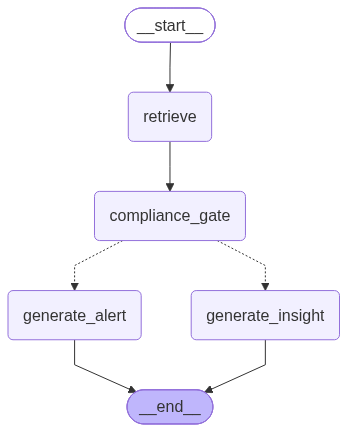

2026-08-06 20:01:15 [INFO] AgentNotebook: Grafo renderizado y mostrado en el notebook.


In [1]:
import logging
from IPython.display import Image, display
from langchain_huggingface import HuggingFaceEmbeddings

# Importar desde los nuevos paquetes de 'core'
from core.rag.vector_db import DualCorpusManager
from core.agentic.core import AgentOrchestrator

# ==========================================
# 0. Configuración de Logging
# ==========================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
logger = logging.getLogger("AgentNotebook")

# ==========================================
# 1. Inicialización de Componentes
# ==========================================
logger.info("Inicializando modelo de Embeddings y Vector DB...")
try:
    # Asegúrate de que la ruta al modelo y a la base de datos sea correcta
    embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
    db_manager = DualCorpusManager(embeddings_model=embeddings, persist_directory="../data/chroma/local_chroma_db")
    db_manager.load_existing_db()
    logger.info("Vector DB cargada exitosamente.")
except Exception as e:
    logger.error(f"Error inicializando componentes de RAG: {e}", exc_info=True)
    raise

# ==========================================
# 2. Instanciación del Orquestador
# ==========================================
logger.info("Instanciando el orquestador del agente...")
try:
    # La ruta a las credenciales es relativa a la raíz del proyecto donde se ejecuta el notebook
    agent_orchestrator = AgentOrchestrator(db_manager=db_manager, credentials_path="../.cred/credentials.yaml")
    logger.info("Orquestador del agente creado exitosamente.")
except Exception as e:
    logger.error(f"Error instanciando AgentOrchestrator: {e}", exc_info=True)
    raise

# ==========================================
# 3. Ejecución del Agente
# ==========================================
# Transcripción de prueba para la PoC
input_state = {
    "transcription": (
        "Visita de seguimiento con la doctora Elena Torres. Le he llevado la ficha técnica "
        "de Glucofast que me pidió la semana pasada. Hemos estado revisando juntos el apartado "
        "de posología. Le he subrayado que, según la ficha, para el segmento de pacientes con "
        "insuficiencia renal moderada, es decir, con un filtrado entre 30 y 60, la indicación de "
        "la marca es ajustar a 25 miligramos al día."
    )
}

logger.info("Iniciando la ejecución del agente LangGraph...")
final_state = agent_orchestrator.invoke(input_state)

# ==========================================
# 4. Visualización de Resultados
# ==========================================
print("\n" + "="*30)
print("=== RESULTADO FINAL DE LA PoC ===")
print("="*30)
print(f"Compliance Validado: {final_state.get('is_compliant', 'N/A')}")
print(f"Razonamiento del Auditor: {final_state.get('compliance_reasoning', 'N/A')}\n")
print("Recomendación del Orquestador:")
print(final_state.get('final_recommendation', 'No se generó ninguna recomendación.'))
print("="*30 + "\n")

# ==========================================
# 5. Visualización del Grafo (Opcional)
# ==========================================
logger.info("Intentando renderizar el grafo del agente...")
try:
    # El método get_graph() debe estar disponible en tu instancia compilada
    graph_image = agent_orchestrator.graph.get_graph().draw_mermaid_png()
    display(Image(graph_image))
    logger.info("Grafo renderizado y mostrado en el notebook.")
except Exception as e:
    logger.error(f"No se pudo renderizar el grafo. Asegúrate de que las dependencias (ej. pygraphviz) estén instaladas: {e}")
